# QC, replicates and PCA

This notebook uses the synthetic three-acquisition example, the smallest study that can be eligible for PCA, to show how coverage, completeness and missing observations are reported, and why a group can be excluded from PCA. Everything here is a fixture: the numbers carry no biological meaning.

The same `fasta-lake analyze-study` and `quantify-study` commands produce the same files for a real study.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Where the bundled examples wrote their outputs. Point this at your own run to reuse the cells.
DATA = Path(os.environ.get("FASTALAKE_TUTORIAL_DATA", "../../tutorial_data")).resolve()
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
pd.set_option("display.width", 140, "display.max_colwidth", 60)
RUN = DATA / "analysis"
assert RUN.is_dir(), f"no analysis run under {DATA}"
print(json.loads((RUN / "VALIDATION.json").read_text()))

{'status': 'PASS', 'scope': 'synthetic three-acquisition workflow, no biological evidence', 'methods': ['sum', 'directlfq'], 'pca_fits': 2, 'automatic_qc': True, 'missing_observation_preserved': True}


## The study matrix, with one missing observation

Group C was not quantified in S2. The blank is preserved through sum and directLFQ quantification; nothing is imputed.

In [2]:
study = pd.read_csv(RUN / "study/study_group_matrix.tsv", sep="\t", index_col=0)
by_sum = pd.read_csv(RUN / "sum/study_group_matrix.tsv", sep="\t", index_col=0)
by_lfq = pd.read_csv(RUN / "directlfq/study_group_matrix.tsv", sep="\t", index_col=0)
pd.concat({"study": study, "sum": by_sum, "directLFQ": by_lfq}, axis=1)

study                  sum               directLFQ                        
                S1     S2     S3     S1     S2     S3        S1          S2          S3
study_group                                                                            
A            100.0  150.0  300.0  100.0  150.0  300.0     100.0  119.522861  109.326511
B             20.0   21.0    8.0   20.0   21.0    8.0      20.0   16.733201    2.915374
C             10.0    NaN   50.0   10.0    NaN   50.0      10.0         NaN   18.221085

## Sample and group QC

`sample_qc.tsv` answers "how much of the study does each acquisition cover"; `group_qc.tsv` answers "in how many acquisitions is each group measured". `pca_complete` is the flag that decides PCA membership: only groups measured in every included acquisition enter the fit.

In [3]:
sample_qc = pd.read_csv(RUN / "sum/qc/sample_qc.tsv", sep="\t")
group_qc = pd.read_csv(RUN / "sum/qc/group_qc.tsv", sep="\t")
display(sample_qc)
group_qc

,sample,total_sample_intensity,num_features_detected,fraction_detected_features,baseline_sum_groups,pca_included
0,S1,130.0,3,1.000000,3,True
1,S2,171.0,2,0.666667,2,True
2,S3,358.0,3,1.000000,3,True


,study_group,total_feature_intensity,num_samples_detected,fraction_detected_samples,pca_complete,pca_eligible
0,A,550.0,3,1.000000,True,True
1,B,49.0,3,1.000000,True,True
2,C,60.0,2,0.666667,False,False


## PCA on the complete core

With three acquisitions and two complete, varying groups, PCA is eligible. The fit uses the log2 layer of the complete core; scores and loadings are written as tables next to the figure.

In [4]:
variance = pd.read_csv(RUN / "sum/qc/pca_variance.tsv", sep="\t")
scores = pd.read_csv(RUN / "sum/qc/pca_scores.tsv", sep="\t")
display(variance)
fig, ax = plt.subplots(figsize=(3.6, 3.2))
for i, row in scores.iterrows():
    ax.scatter(row["PC1"], row["PC2"], color=OKABE_ITO[i], s=40); ax.annotate(row["sample"], (row["PC1"], row["PC2"]), xytext=(4, 4), textcoords="offset points")
ax.set_xlabel(f"PC1 ({variance.loc[0, 'variance_ratio']:.0%})"); ax.set_ylabel(f"PC2 ({variance.loc[1, 'variance_ratio']:.0%})")
plt.tight_layout()

,component,variance_ratio,variance
0,PC1,0.956884,1.203326
1,PC2,0.043116,0.054221


## What the summary records

`qc/summary.json` states the transformation, the PCA decision and the CV setting in words, next to the checksums of every input. Replicate CV needs declared replicate sets; this fixture declares none, so the CV table is empty and the summary says why.

In [5]:
summary = json.loads((RUN / "sum/qc/summary.json").read_text())
print("transformations:", summary["transformations"])
print("pca:", json.dumps(summary["pca"], indent=1)[:500])
print("cv:", json.dumps(summary["cv"], indent=1)[:300])
cv = pd.read_csv(RUN / "sum/qc/replicate_cv.tsv.gz", sep="\t")
print("replicate CV rows:", len(cv))

transformations: Positive linear X; log2 layer; no normalization or imputation
pca: {
 "status": "PASS",
 "samples": 3,
 "groups": 2,
 "feature_centered": true,
 "unit_variance_scaled": false
}
cv: {
 "replicate_column": null,
 "min_valid": 2,
 "upstream_ddof": 0,
 "sample_cv_correction": "sqrt(n/(n-1)); n is observed values"
}
replicate CV rows: 0


## The same report on a real study

The CAMPI example has only two acquisitions. Its QC summary records the PCA exclusion in the same field, so a reader of any study can see whether PCA was fitted and why not.

In [6]:
campi = DATA / "campi/study/qc/summary.json"
if campi.exists():
    print(json.dumps(json.loads(campi.read_text())["pca"], indent=1)[:600])

{
 "status": "SKIPPED: need at least three nonempty samples and two complete varying groups",
 "samples": 2,
 "groups": 126,
 "feature_centered": true,
 "unit_variance_scaled": false
}


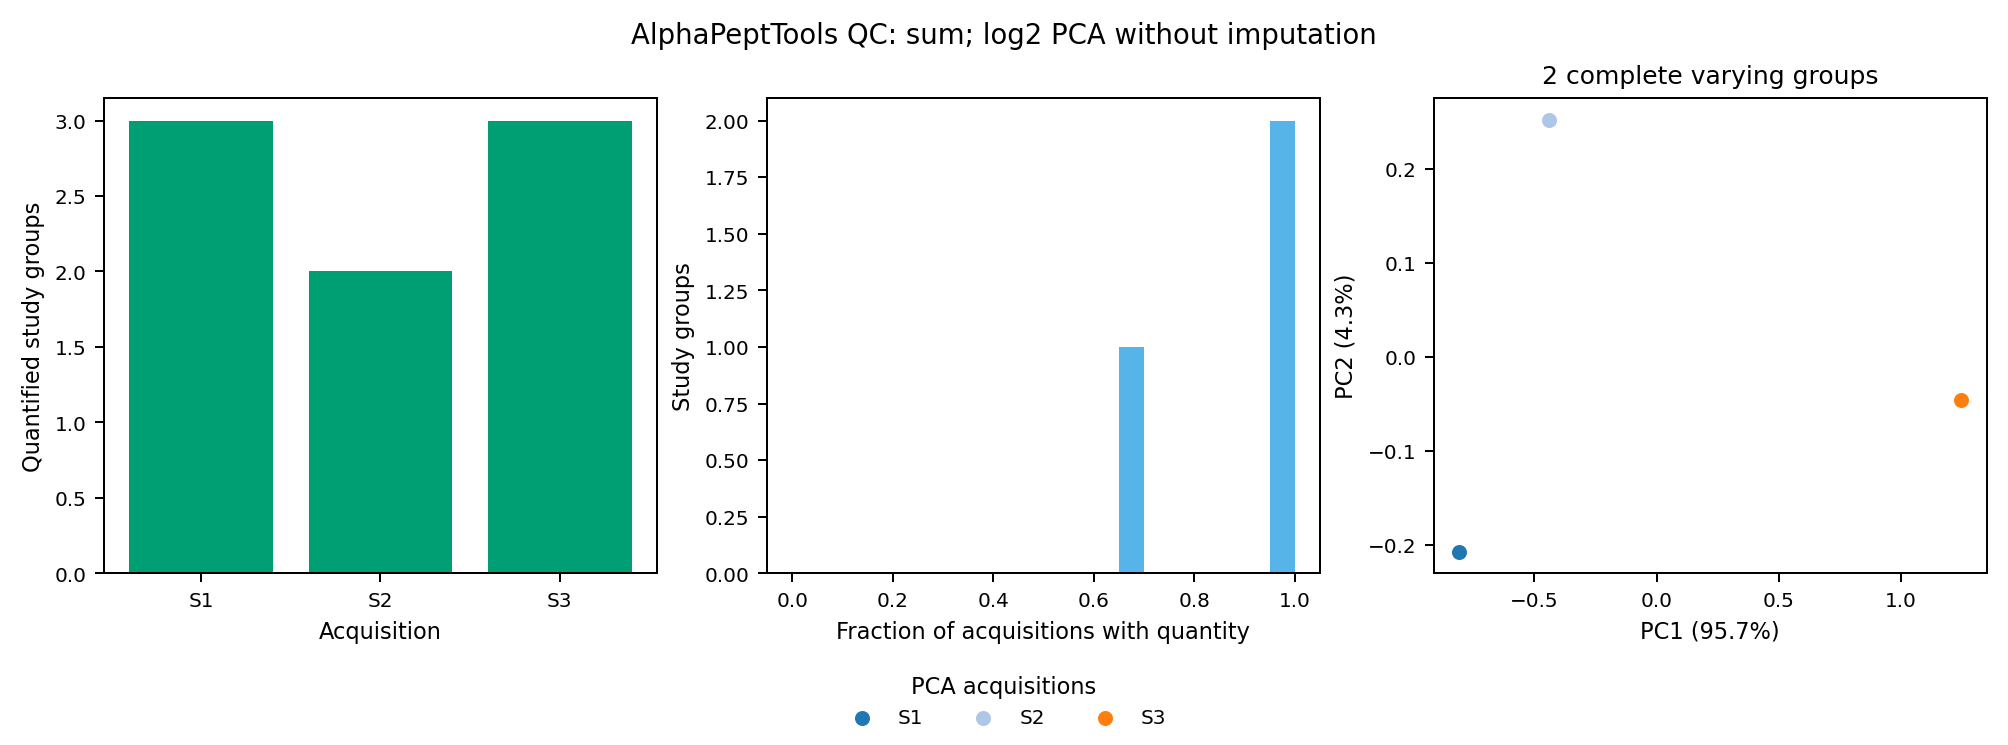

In [7]:
from IPython.display import Image
Image(filename=str(RUN / "sum/qc/QC_overview.png"), width=760)